# 9 Quantum Computing — Moons Classification

## 9.1
Follow the [PennyLane QNN tutorial](https://pennylane.ai/qml/demos/tutorial_qnn_module_torch) and create a quantum neural network to classify the Moons dataset.

## 9.2
Compare the quantum neural network to a classical neural network (without any quantum layer).

In [14]:
!pip install -q scikit-learn pennylane torch matplotlib

In [15]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

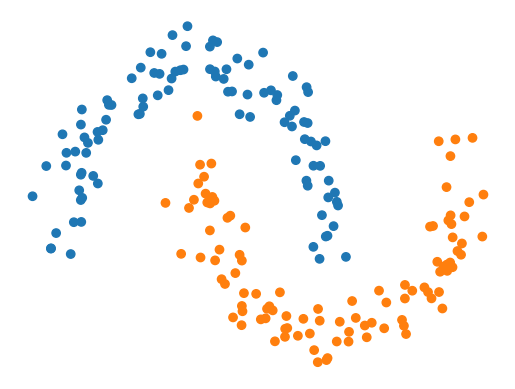

In [16]:
# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

X, y = make_moons(n_samples=200, noise=0.1)
y_ = torch.unsqueeze(torch.tensor(y), 1)  # used for one-hot encoded labels
y_hot = torch.scatter(torch.zeros((200, 2)), 1, y_, 1)

c = ["#1f77b4" if y_ == 0 else "#ff7f0e" for y_ in y]  # colours for each class
plt.axis("off")
plt.scatter(X[:, 0], X[:, 1], c=c)
plt.show()

In [17]:
import pennylane as qml

n_qubits = 2
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def qnode(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

In [18]:
n_layers = 6
weight_shapes = {"weights": (n_layers, n_qubits)}
qlayer = qml.qnn.TorchLayer(qnode, weight_shapes)
clayer_1 = nn.Linear(2, 2)
clayer_2 = nn.Linear(2, 2)

# Model 1 — Classical only (no quantum layer)

In [19]:
model1 = nn.Sequential(nn.Linear(2, 2), nn.ReLU(), nn.Linear(2, 2), nn.Softmax(dim=1))
opt1 = torch.optim.SGD(model1.parameters(), lr=0.2)
loss_fn = nn.L1Loss()

# Prepare tensors (tutorial style)
X_all = torch.tensor(X, requires_grad=True).float()
y_hot_all = y_hot.float()
X_train, X_val = X_all[:150], X_all[150:]
y_train, y_val = y_hot_all[:150], y_hot_all[150:]

batch_size = 5
batches = 150 // batch_size
train_loader = torch.utils.data.DataLoader(
    list(zip(X_train, y_train)), batch_size=batch_size, shuffle=True, drop_last=True
)
losses1 = []
epochs = 6
for epoch in range(epochs):
    running_loss = 0
    for xs, ys in train_loader:
        opt1.zero_grad()
        loss_evaluated = loss_fn(model1(xs), ys)
        loss_evaluated.backward()
        opt1.step()
        running_loss += loss_evaluated
    avg_loss = running_loss / batches
    losses1.append(avg_loss.item())
    print("Average loss over epoch {}: {:.4f}".format(epoch + 1, avg_loss))

y_pred = model1(X_val)
predictions = torch.argmax(y_pred, axis=1).detach().numpy()
correct = [1 if p == p_true else 0 for p, p_true in zip(predictions, y[150:])]
accuracy = sum(correct) / len(correct)
acc1 = accuracy
print(f"Accuracy: {accuracy * 100}%")

Average loss over epoch 1: 0.5016
Average loss over epoch 2: 0.4960
Average loss over epoch 3: 0.4842
Average loss over epoch 4: 0.4452
Average loss over epoch 5: 0.3782
Average loss over epoch 6: 0.2986
Accuracy: 84.0%


# Model 2 — Hybrid quantum-classical (with quantum layer)

In [20]:
softmax = nn.Softmax(dim=1)
model2 = nn.Sequential(clayer_1, qlayer, clayer_2, softmax)
opt2 = torch.optim.SGD(model2.parameters(), lr=0.2)
loss_fn = nn.L1Loss()

In [21]:
epochs = 6
losses2 = []
for epoch in range(epochs):
    running_loss = 0
    for xs, ys in train_loader:
        opt2.zero_grad()
        loss_evaluated = loss_fn(model2(xs), ys)
        loss_evaluated.backward()
        opt2.step()
        running_loss += loss_evaluated

    avg_loss = running_loss / batches
    losses2.append(avg_loss.item())
    print("Average loss over epoch {}: {:.4f}".format(epoch + 1, avg_loss))

y_pred = model2(X_val)
predictions = torch.argmax(y_pred, axis=1).detach().numpy()
correct = [1 if p == p_true else 0 for p, p_true in zip(predictions, y[150:])]
accuracy = sum(correct) / len(correct)
acc2 = accuracy
print(f"Accuracy: {accuracy * 100}%")

Average loss over epoch 1: 0.5021
Average loss over epoch 2: 0.4740
Average loss over epoch 3: 0.3824
Average loss over epoch 4: 0.2738
Average loss over epoch 5: 0.2138
Average loss over epoch 6: 0.1906
Accuracy: 82.0%


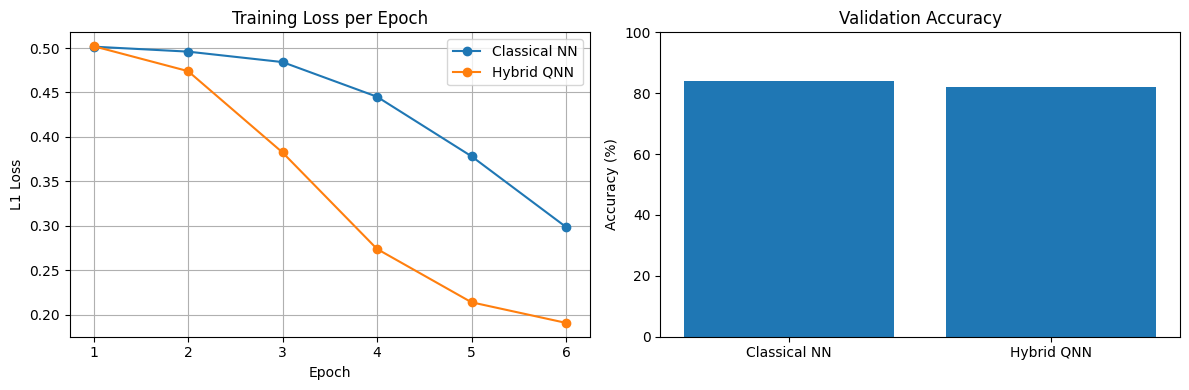

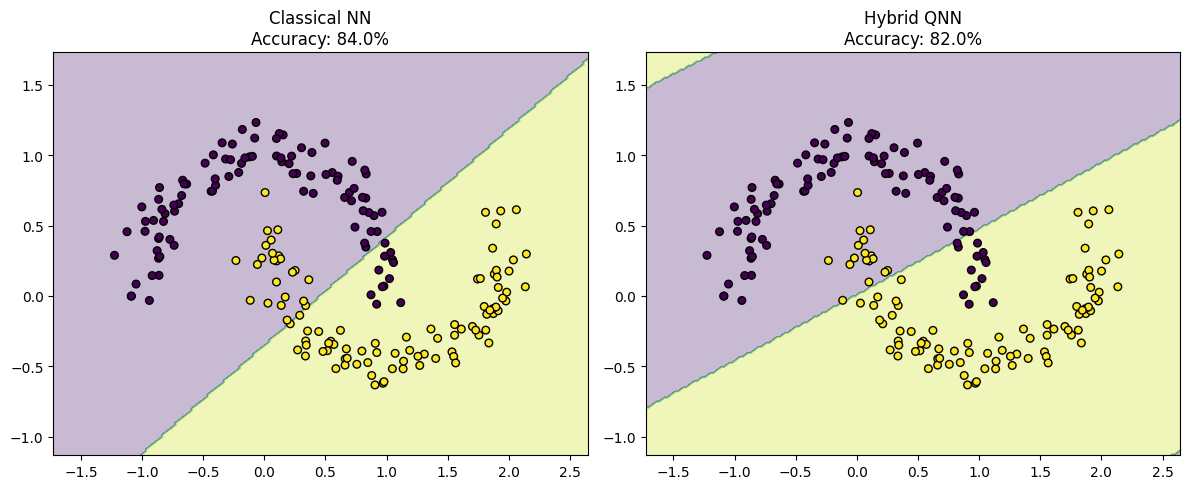

,Model,Accuracy (%),Final Training Loss
0,Classical NN,84.0,0.298551
1,Hybrid Quantum-Classical NN,82.0,0.190563


In [22]:
# --- Visualisierung der Ergebnisse ---

def plot_decision_boundary(ax, model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.tensor(grid, dtype=torch.float32)

    with torch.no_grad():
        probs = model(grid_tensor)
        preds = torch.argmax(probs, dim=1).numpy()

    preds = preds.reshape(xx.shape)

    ax.contourf(xx, yy, preds, alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", s=30)
    ax.set_title(title)

# Loss-Kurven + Accuracy
epochs_range = np.arange(1, len(losses1) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, losses1, marker="o", label="Classical NN")
axes[0].plot(epochs_range, losses2, marker="o", label="Hybrid QNN")
axes[0].set_title("Training Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("L1 Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].bar(["Classical NN", "Hybrid QNN"], [acc1 * 100, acc2 * 100])
axes[1].set_title("Validation Accuracy")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

# Decision boundaries
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_decision_boundary(axes[0], model1, X, y, f"Classical NN\nAccuracy: {acc1*100:.1f}%")
plot_decision_boundary(axes[1], model2, X, y, f"Hybrid QNN\nAccuracy: {acc2*100:.1f}%")

plt.tight_layout()
plt.show()

# Kleine Ergebnistabelle
df_results = pd.DataFrame({
    "Model": ["Classical NN", "Hybrid Quantum-Classical NN"],
    "Accuracy (%)": [acc1 * 100, acc2 * 100],
    "Final Training Loss": [losses1[-1], losses2[-1]]
})

display(df_results)

The hybrid quantum-classical model showed a faster decrease in training loss, but the classical neural network achieved slightly higher validation accuracy (84.0% vs. 82.0%); the plotted decision boundaries indicate that both models learned the two-moons structure, with the classical model generalizing slightly better in this experiment